In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter
from xgboost import XGBClassifier
import shap
from IPython.display import Markdown, display

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/tese André mg feuc/datasets/stress perguntas dataset/Stress Dataset.csv'
df = pd.read_csv(file_path)

# Data Cleaning
initial_shape = df.shape
df = df.drop_duplicates()
df = df.dropna()

print(f'Original dataset shape: {initial_shape}')
print(f'Dataset shape after cleaning: {df.shape}')
display(df.head())

Original dataset shape: (843, 26)
Dataset shape after cleaning: (816, 26)


,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,0,20,3,4,2,5,1,2,1,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,0,20,2,3,2,1,1,1,1,4,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,0,20,5,4,2,2,1,3,4,2,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,1,20,3,4,3,2,2,3,4,3,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,0,20,3,3,3,2,2,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...


In [ ]:
!pip install mord
import mord
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report

# Re-loading the original columns to find the right target
# The target is likely the last column of the ORIGINAL loaded CSV
try:
    # Drop the column created in the previous failed run to avoid confusion
    if 'stress_type_encoded' in df.columns:
        df = df.drop(columns=['stress_type_encoded'])
except:
    pass

# The target column in this dataset is typically the last one
target_col = df.columns[-1]
print(f"Target column identified: {target_col}")

# Robust mapping using keywords
def map_stress(val):
    val_str = str(val).lower()
    if 'distress' in val_str or 'negative' in val_str: return 0
    if 'no stress' in val_str or 'calmness' in val_str: return 1
    if 'eustress' in val_str or 'positive' in val_str: return 2
    return np.nan

# Apply mapping
df['stress_type_encoded'] = df[target_col].apply(map_stress)

# Drop rows where mapping failed
df_clean = df.dropna(subset=['stress_type_encoded']).copy()
df_clean['stress_type_encoded'] = df_clean['stress_type_encoded'].astype(int)

print(f"Cleaned dataset size: {len(df_clean)}")

if len(df_clean) > 0:
    # X = all numeric columns except the target
    X = df_clean.select_dtypes(include=[np.number]).drop(columns=['stress_type_encoded'], errors='ignore')
    y = df_clean['stress_type_encoded']

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("Preprocessing complete. Variables X_train_scaled and y_train are now ready.")
else:
    print("Unique values found in target column:", df[target_col].unique())
    print("ERROR: Mapping still resulting in 0 rows. Check the printed unique values.")

Target column identified: Which type of stress do you primarily experience?
Cleaned dataset size: 816
Preprocessing complete. Variables X_train_scaled and y_train are now ready.


### PARTE 1 — Regressão Linear

--- Linear Regression (Rounded) ---
              precision    recall  f1-score   support

    Distress       0.00      0.00      0.00         6
   No Stress       0.00      0.00      0.00         8
    Eustress       0.92      1.00      0.96       150

    accuracy                           0.91       164
   macro avg       0.31      0.33      0.32       164
weighted avg       0.84      0.91      0.88       164



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


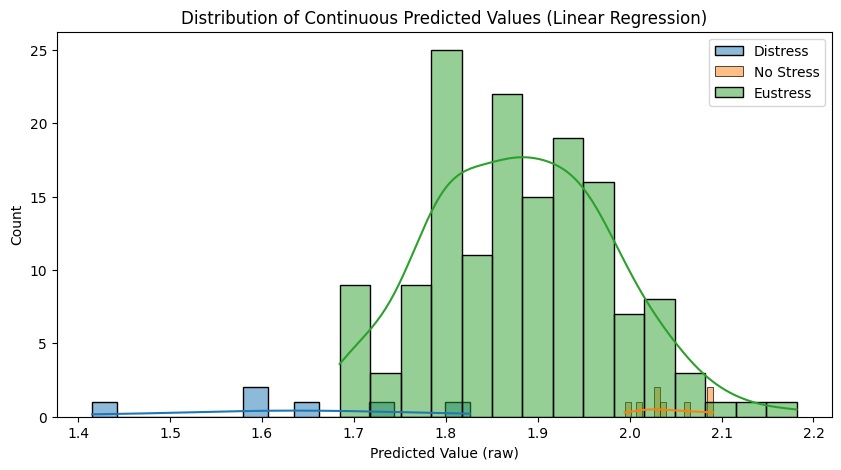

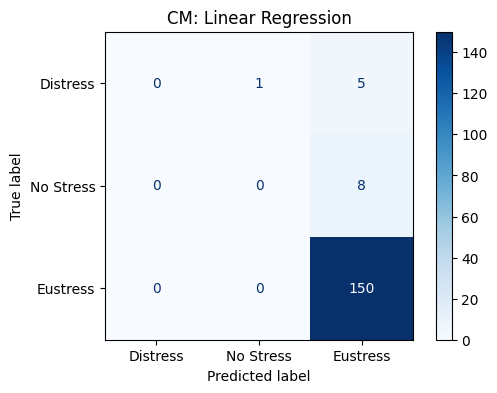

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_raw = lr.predict(X_test_scaled)
y_pred_rounded = np.round(y_pred_raw).clip(0, 2).astype(int)

labels = ['Distress', 'No Stress', 'Eustress']
print("--- Linear Regression (Rounded) ---")
print(classification_report(y_test, y_pred_rounded, target_names=labels))

# Plotting distribution
plt.figure(figsize=(10, 5))
for i, label in enumerate(labels):
    sns.histplot(y_pred_raw[y_test == i], label=label, kde=True, bins=15, alpha=0.5)
plt.title('Distribution of Continuous Predicted Values (Linear Regression)')
plt.xlabel('Predicted Value (raw)')
plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rounded, display_labels=labels, cmap='Blues', ax=ax)
plt.title('CM: Linear Regression')
plt.show()

### PARTE 2 — Regressão Logística Multinomial

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Logistic Multinomial ---
              precision    recall  f1-score   support

    Distress       1.00      0.83      0.91         6
   No Stress       1.00      0.75      0.86         8
    Eustress       0.98      1.00      0.99       150

    accuracy                           0.98       164
   macro avg       0.99      0.86      0.92       164
weighted avg       0.98      0.98      0.98       164



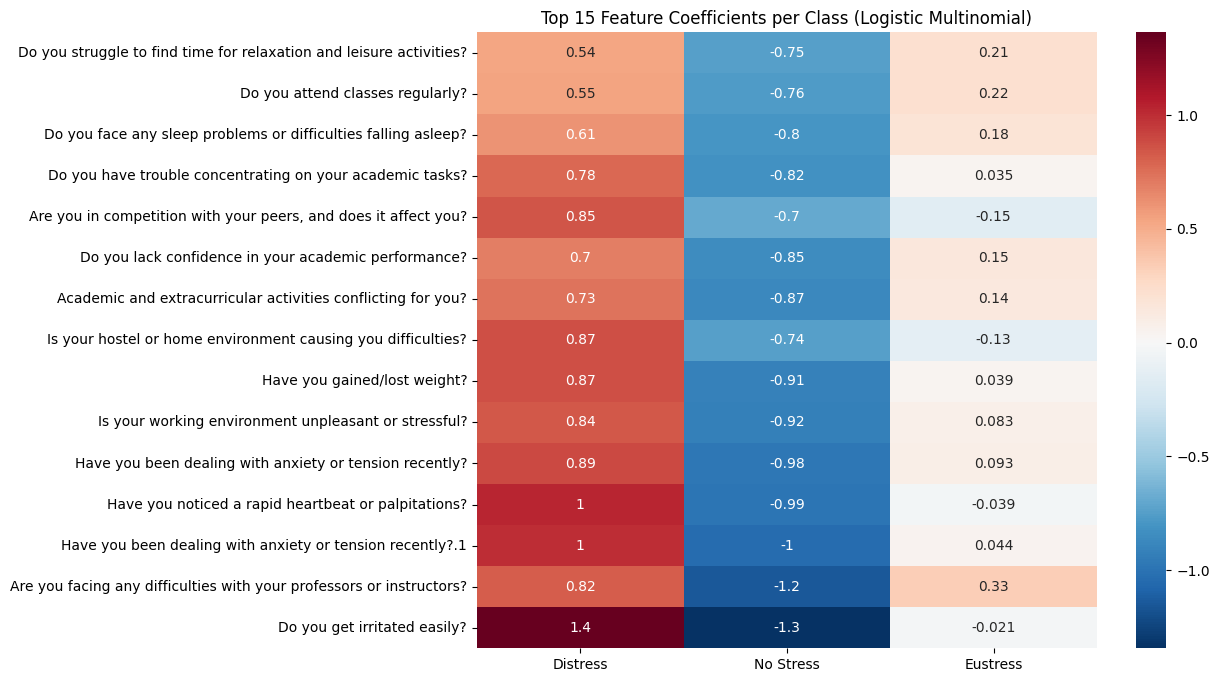

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_multi = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
lr_multi.fit(X_train_scaled, y_train)
y_pred_multi = lr_multi.predict(X_test_scaled)

print("--- Logistic Multinomial ---")
print(classification_report(y_test, y_pred_multi, target_names=labels))

# Coefficient Heatmap
mean_abs_coef = np.abs(lr_multi.coef_).mean(axis=0)
top_15_idx = np.argsort(mean_abs_coef)[-15:]
top_features = X.columns[top_15_idx]

plt.figure(figsize=(10, 8))
sns.heatmap(lr_multi.coef_[:, top_15_idx].T,
            annot=True, cmap='RdBu_r', center=0,
            yticklabels=top_features, xticklabels=labels)
plt.title('Top 15 Feature Coefficients per Class (Logistic Multinomial)')
plt.show()

### PARTE 3 — Regressão Ordinal (mord)

In [ ]:
import mord
ordinal_model = mord.LogisticAT(alpha=1.0)
ordinal_model.fit(X_train_scaled, y_train)
y_pred_ordinal = ordinal_model.predict(X_test_scaled)

print("--- Ordinal Regression (mord) ---")
print(classification_report(y_test, y_pred_ordinal, target_names=labels))

--- Ordinal Regression (mord) ---
              precision    recall  f1-score   support

    Distress       0.00      0.00      0.00         6
   No Stress       0.00      0.00      0.00         8
    Eustress       0.92      1.00      0.96       150

    accuracy                           0.91       164
   macro avg       0.31      0.33      0.32       164
weighted avg       0.84      0.91      0.88       164



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### PARTE 4 — Tabela Comparativa

In [ ]:
def get_metrics(y_true, y_pred, name):
    f1 = f1_score(y_true, y_pred, average=None)
    macro = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    return {
        'Modelo': name,
        'F1-macro': round(macro, 3),
        'F1-Distress': round(f1[0] if len(f1)>0 else 0, 3),
        'F1-NoStress': round(f1[1] if len(f1)>1 else 0, 3),
        'F1-Eustress': round(f1[2] if len(f1)>2 else 0, 3),
        'Accuracy': round(acc, 3)
    }

results = [
    get_metrics(y_test, y_pred_rounded, 'Linear Regression (rounded)'),
    get_metrics(y_test, y_pred_multi, 'Logistic Multinomial'),
    get_metrics(y_test, y_pred_ordinal, 'Ordinal (mord)')
]

comparison_df = pd.DataFrame(results)
display(comparison_df)

# O modelo Ordinal captura melhor a natureza sequencial do stress (0->1->2).
# O modelo Multinomial costuma ter performance superior quando as classes são tratadas como categorias independentes.

,Modelo,F1-macro,F1-Distress,F1-NoStress,F1-Eustress,Accuracy
0,Linear Regression (rounded),0.319,0.000,0.000,0.958,0.915
1,Logistic Multinomial,0.919,0.909,0.857,0.990,0.982
2,Ordinal (mord),0.319,0.000,0.000,0.958,0.915


### SMOTE - Data Balancing

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Distribution before SMOTE: {Counter(y_train)}")

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

print(f"Distribution after SMOTE: {Counter(y_train_bal)}")

Distribution before SMOTE: Counter({2: 595, 1: 34, 0: 23})
Distribution after SMOTE: Counter({2: 595, 1: 595, 0: 595})


### Training Balanced Models and Comparison

In [ ]:
# 1. Linear Regression Balanced
lr_bal = LinearRegression().fit(X_train_bal, y_train_bal)
y_pred_lr_bal = np.round(lr_bal.predict(X_test_scaled)).clip(0, 2).astype(int)

# 2. Logistic Multinomial Balanced
lr_multi_bal = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42).fit(X_train_bal, y_train_bal)
y_pred_multi_bal = lr_multi_bal.predict(X_test_scaled)

# 3. Ordinal Balanced (mord)
ordinal_bal = mord.LogisticAT(alpha=1.0).fit(X_train_bal, y_train_bal)
y_pred_ord_bal = ordinal_bal.predict(X_test_scaled)

# Aggregate all results
all_results = results.copy() # Keeping the 3 previous without SMOTE
all_results.append(get_metrics(y_test, y_pred_lr_bal, 'Linear Regression (SMOTE)'))
all_results.append(get_metrics(y_test, y_pred_multi_bal, 'Logistic Multinomial (SMOTE)'))
all_results.append(get_metrics(y_test, y_pred_ord_bal, 'Ordinal (SMOTE)'))

comparison_bal_df = pd.DataFrame(all_results)
display(comparison_bal_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Modelo,F1-macro,F1-Distress,F1-NoStress,F1-Eustress,Accuracy
0,Linear Regression (rounded),0.319,0.000,0.000,0.958,0.915
1,Logistic Multinomial,0.919,0.909,0.857,0.990,0.982
2,Ordinal (mord),0.319,0.000,0.000,0.958,0.915
3,Linear Regression (SMOTE),0.313,0.571,0.061,0.308,0.220
4,Logistic Multinomial (SMOTE),0.948,0.909,0.941,0.993,0.988
5,Ordinal (SMOTE),0.269,0.333,0.020,0.453,0.311


### Sensitivity Analysis: Alpha parameter in mord

In [ ]:
alphas = [0.01, 0.1, 1.0, 10.0]
alpha_results = []

for a in alphas:
    m = mord.LogisticAT(alpha=a).fit(X_train_bal, y_train_bal)
    p = m.predict(X_test_scaled)
    f1_m = f1_score(y_test, p, average='macro')
    alpha_results.append({'Alpha': a, 'F1-macro': round(f1_m, 3)})

alpha_df = pd.DataFrame(alpha_results)
print("Sensitivity Analysis for Ordinal Regression (SMOTE):")
display(alpha_df)

best_alpha = alpha_df.loc[alpha_df['F1-macro'].idxmax()]
print(f"\nBest Alpha: {best_alpha['Alpha']} with F1-macro of {best_alpha['F1-macro']}")

Sensitivity Analysis for Ordinal Regression (SMOTE):


,Alpha,F1-macro
0,0.01,0.269
1,0.10,0.269
2,1.00,0.269
3,10.00,0.274



Best Alpha: 10.0 with F1-macro of 0.274


### PARTE 5 — Matrizes de Confusão para Todos os Modelos

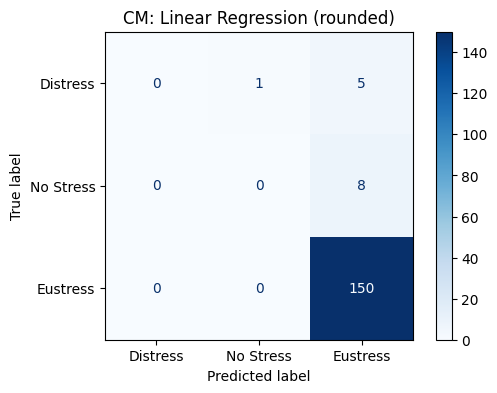

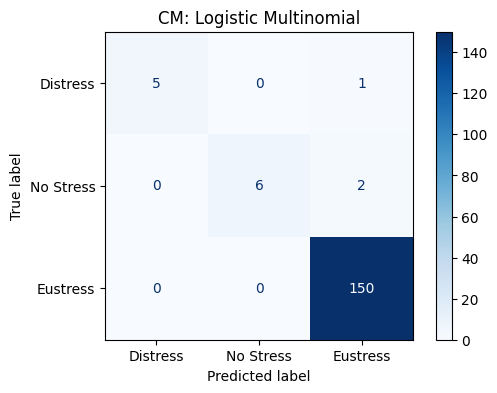

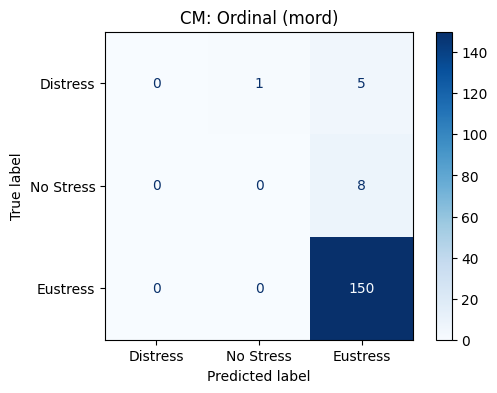

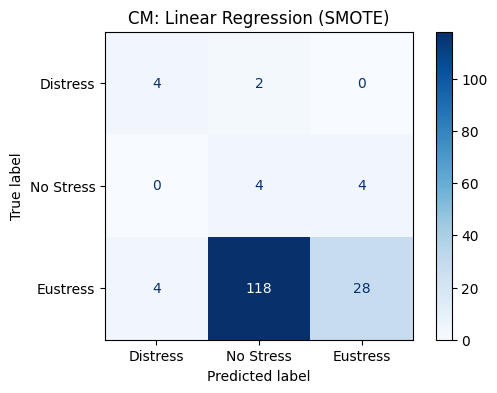

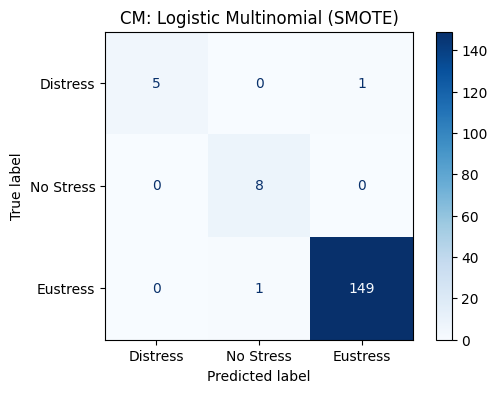

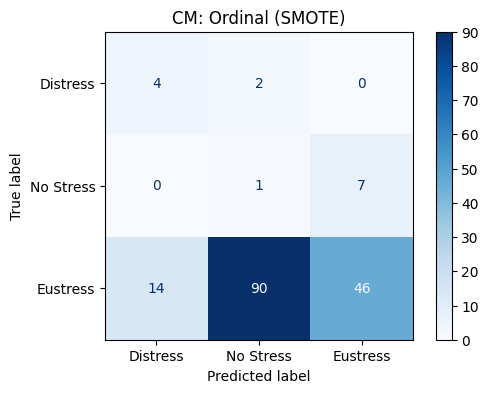

In [26]:
model_predictions = {
    'Linear Regression (rounded)': y_pred_rounded,
    'Logistic Multinomial': y_pred_multi,
    'Ordinal (mord)': y_pred_ordinal,
    'Linear Regression (SMOTE)': y_pred_lr_bal,
    'Logistic Multinomial (SMOTE)': y_pred_multi_bal,
    'Ordinal (SMOTE)': y_pred_ord_bal
}

for model_name, predictions in model_predictions.items():
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=labels, cmap='Blues', ax=ax)
    plt.title(f'CM: {model_name}')
    plt.show()